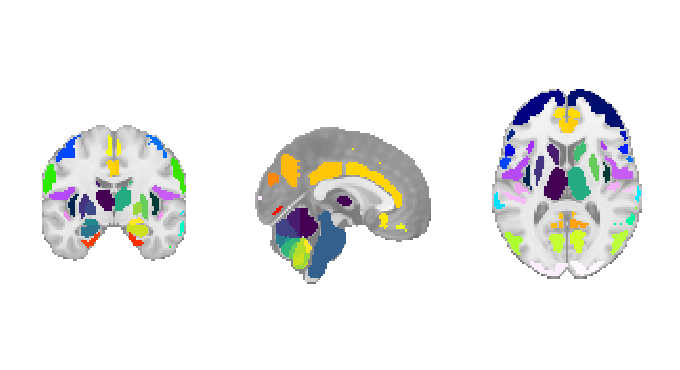

In [ ]:
from nilearn import plotting
from nilearn.datasets import load_mni152_template
from nilearn.image import load_img, new_img_like
import numpy as np
import matplotlib.pyplot as plt

# Paths to your atlases
ATLAS1 = "/mnt/moritz/CEBRA_project/atlas/HarvardOxford-cortl-maxprob-thr50-2mm-without_background.nii.gz"
ATLAS2 = "/mnt/moritz/CEBRA_project/atlas/HarvardOxford-sub-maxprob-thr50-2mm-only_subcortical_regions.nii.gz"
ATLAS3 = "/mnt/moritz/CEBRA_project/atlas/atl-Anatom_space-MNI_dseg_resampled_to_MNI.nii"

# Load the atlases
atlas1 = load_img(ATLAS1)
atlas2 = load_img(ATLAS2)
atlas3 = load_img(ATLAS3)

# Load MNI template (brain)
mni_template = load_mni152_template()

# Plot the first atlas on the MNI template, applying threshold to mask out the background
fig = plotting.plot_roi(atlas1, draw_cross=False, cut_coords=(0, -10, 10), colorbar=False, annotate=False, alpha=1, threshold=0.1)

# Add the second atlas as an overlay with transparency
fig.add_overlay(atlas2, transparency=1)

# Add the third atlas as an overlay with transparency
fig.add_overlay(atlas3, transparency=1)

# Remove the axes and labels by disabling the frame
fig.frame_on = False

# Set up the matplotlib figure for transparent background saving
plt.gcf().set_facecolor('none')  # Make sure figure has no background color
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)  # Adjust to avoid extra margins

# Save the plot as a .svg file with a transparent background
plt.savefig("Figure_1/atlases_overlay.svg", transparent=True, bbox_inches='tight', pad_inches=0)

# Show the plot
plotting.show()






In [ ]:
from nilearn import plotting
from nilearn.datasets import load_mni152_template
from nilearn.image import load_img
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Paths to your atlases
ATLAS1 = "/mnt/moritz/CEBRA_project/atlas/HarvardOxford-cortl-maxprob-thr50-2mm-without_background.nii.gz"
ATLAS2 = "/mnt/moritz/CEBRA_project/atlas/HarvardOxford-sub-maxprob-thr50-2mm-only_subcortical_regions.nii.gz"
ATLAS3 = "/mnt/moritz/CEBRA_project/atlas/atl-Anatom_space-MNI_dseg_resampled_to_MNI.nii"

# Load the atlases
atlas1 = load_img(ATLAS1)
atlas2 = load_img(ATLAS2)
atlas3 = load_img(ATLAS3)

# Load MNI template
mni_template = load_mni152_template()

# --- Define CEBRA-like Colormaps ---
# 1. Teal/Cyan range for the first atlas
cmap_cebra_teal = plt.cm.GnBu_r  # Green-Blue reversed (or use 'winter')

# 2. Deep Purple/Indigo range for the second atlas
cmap_cebra_purple = plt.cm.Purples  # Standard Purples (or 'BuPu')

# 3. Gold/Yellow/Orange range for the third atlas (High contrast)
cmap_cebra_gold = plt.cm.Wistia  # Yellow-Orange

# --- Plotting ---

# Plot the first atlas (Cortical) with Teal theme
# Note: 'alpha' controls transparency (0=transparent, 1=opaque)
fig = plotting.plot_roi(
    atlas1, 
    bg_img=mni_template,
    draw_cross=False, 
    cut_coords=(0, -10, 10), 
    colorbar=False, 
    annotate=False, 
    alpha=0.8,         # Standard opacity
    threshold=0.1, 
    cmap=cmap_cebra_teal
)

# Add the second atlas (Subcortical) with Purple theme
fig.add_overlay(
    atlas2, 
    cmap=cmap_cebra_purple, 
    alpha=0.8
)

# Add the third atlas (Anatom) with Gold theme
fig.add_overlay(
    atlas3, 
    cmap=cmap_cebra_gold, 
    alpha=0.7 # Slightly lower alpha to see through if it overlaps significantly
)

# Remove the axes and labels by disabling the frame
fig.frame_on = False

# Set up the matplotlib figure for transparent background saving
plt.gcf().set_facecolor('none')
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

# Save the plot
plt.savefig("Figure_1/atlases_overlay_cebra.svg", transparent=True, bbox_inches='tight', pad_inches=0)

# Show the plot
plotting.show()